# Gene Embedding Reproducibility

In [1]:
!python tasks/gene_embedding.py \
  --input pancreas.h5ad \
  --output nano_cellfm_gene_embeddings.npy \
  --model CellFM-80M \
  --batch-size 256

#(N, G, 1536)

Saved embeddings: nano_cellfm_gene_embeddings.npy
Shape: (15681, 1000, 1536)


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import scanpy as sc

from model import CellFM

official = np.load("official_cellfm_gene_embeddings.npy")  # (128, 1,000, 1,536)

adata = sc.read_h5ad("pancreas.h5ad")
gene_info = pd.read_csv("assets/CellFM-80M/expand_gene_info.csv", index_col=0)

geneset = {g: i + 1 for i, g in enumerate(gene_info.index)}
gene_ids = np.array([geneset[g] if g in geneset else 0 for g in adata.var_names], dtype=np.int64)

x = adata.X.A if hasattr(adata.X, "A") else np.asarray(adata.X)
x = x.astype(np.float32)

expr = torch.from_numpy(x[:1000])
gene = torch.from_numpy(gene_ids[None, :].repeat(1000, axis=0))

zero_gene_mask = (x[:1000] != 0).astype(np.float32)
zero_idx = torch.from_numpy(
    np.concatenate(
        [np.ones((zero_gene_mask.shape[0], 1), dtype=np.float32), zero_gene_mask],
        axis=1,
    )
)

model = CellFM.from_pretrained("CellFM-80M").eval()

with torch.no_grad():
    nano = model.encode_genes(expr, gene, zero_idx).cpu().numpy()
print(nano.shape)

off = torch.from_numpy(official).reshape(-1, 1536)
nan = torch.from_numpy(nano).reshape(-1, 1536)

cos = F.cosine_similarity(off, nan, dim=-1)

print("official CellFM:", official.shape)
print("nano-CellFM:", nano.shape)
print("mean cosine:", cos.mean().item())
print("median cosine:", cos.median().item())
print("min cosine:", cos.min().item())
print("mean abs diff:", torch.mean(torch.abs(off - nan)).item())
print("max abs diff:", torch.max(torch.abs(off - nan)).item())

(1000, 1000, 1536)
official CellFM: (1000, 1000, 1536)
nano-CellFM: (1000, 1000, 1536)
mean cosine: 1.0
median cosine: 1.0
min cosine: 0.9999996423721313
mean abs diff: 6.242452599281023e-08
max abs diff: 3.814697265625e-06


In [2]:
import time
import subprocess
import numpy as np

from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist


nano_path = "nano_cellfm_gene_embeddings.npy"

cmd = [
    "python", "tasks/gene_embedding.py",
    "--input", "pancreas.h5ad",
    "--output", nano_path,
    "--model", "CellFM-80M",
    "--batch-size", "256",
]

start = time.perf_counter()
subprocess.run(cmd, check=True)
elapsed = time.perf_counter() - start

nano = np.load(nano_path)

print("nano-CellFM:", nano.shape)

# -------------------------
# PCA spectrum
# -------------------------
nano_cell = nano.mean(axis=1)

n_pca = min(50, nano_cell.shape[0], nano_cell.shape[1])
pca = PCA(n_components=n_pca).fit(nano_cell)

print("PCA explained variance ratio:")
print(pca.explained_variance_ratio_)

print("PCA spectrum cumulative variance:")
print(np.cumsum(pca.explained_variance_ratio_))


# -------------------------
# Pairwise distance structure
# -------------------------
nano_dist = pdist(nano_cell, metric="euclidean")

print("Pairwise distance mean:", nano_dist.mean())
print("Pairwise distance std:", nano_dist.std())
print("Pairwise distance min:", nano_dist.min())
print("Pairwise distance max:", nano_dist.max())


# -------------------------
# Runtime metrics
# -------------------------
total_cells = nano.shape[0]
per_cell = elapsed / total_cells
throughput = total_cells / elapsed

print(f"Total ({total_cells:,} cells): {elapsed:.4f} s")
print(f"Per cell: {per_cell:.6f} s/cell")
print(f"Throughput: {throughput:.2f} cells/s")
print("Peak GPU: measure inside tasks/gene_embedding.py")

Saved embeddings: nano_cellfm_gene_embeddings.npy
Shape: (15681, 1000, 1536)
nano-CellFM: (15681, 1000, 1536)
PCA explained variance ratio:
[9.9965787e-01 1.9810366e-04 7.8296587e-05 1.5712427e-05 1.8466898e-06
 8.6666398e-07 7.7242464e-07 7.5184045e-07 6.5782848e-07 6.5128324e-07
 6.4240595e-07 6.0672335e-07 5.6518223e-07 5.5296363e-07 5.3888061e-07
 5.0196769e-07 4.7450476e-07 4.5656674e-07 4.3946352e-07 4.2916730e-07
 4.2242868e-07 4.1283582e-07 4.0320444e-07 3.8426461e-07 3.8071698e-07
 3.7366107e-07 3.6810238e-07 3.6067777e-07 3.4608217e-07 3.3991071e-07
 3.3604027e-07 3.3266278e-07 3.2359316e-07 3.1598387e-07 3.0918056e-07
 2.9729213e-07 2.9600608e-07 2.8822470e-07 2.8204406e-07 2.7885184e-07
 2.7230610e-07 2.6686155e-07 2.5857312e-07 2.5663226e-07 2.5479915e-07
 2.5060558e-07 2.4543317e-07 2.4175287e-07 2.3932131e-07 2.3620662e-07]
PCA spectrum cumulative variance:
[0.99965787 0.999856   0.9999343  0.99995005 0.9999519  0.9999528
 0.99995357 0.99995434 0.999955   0.99995565 0.99

### Visualization

/aiau001_scratch/hqn0001/envs/hub_test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


official: (1000, 1000, 1536)
nano: (1000, 1000, 1536)


/aiau001_scratch/hqn0001/envs/hub_test/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/aiau001_scratch/hqn0001/envs/hub_test/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/aiau001_scratch/hqn0001/envs/hub_test/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/aiau001_scratch/hqn0001/envs/hub_test/lib/python3.10/site-packages/um

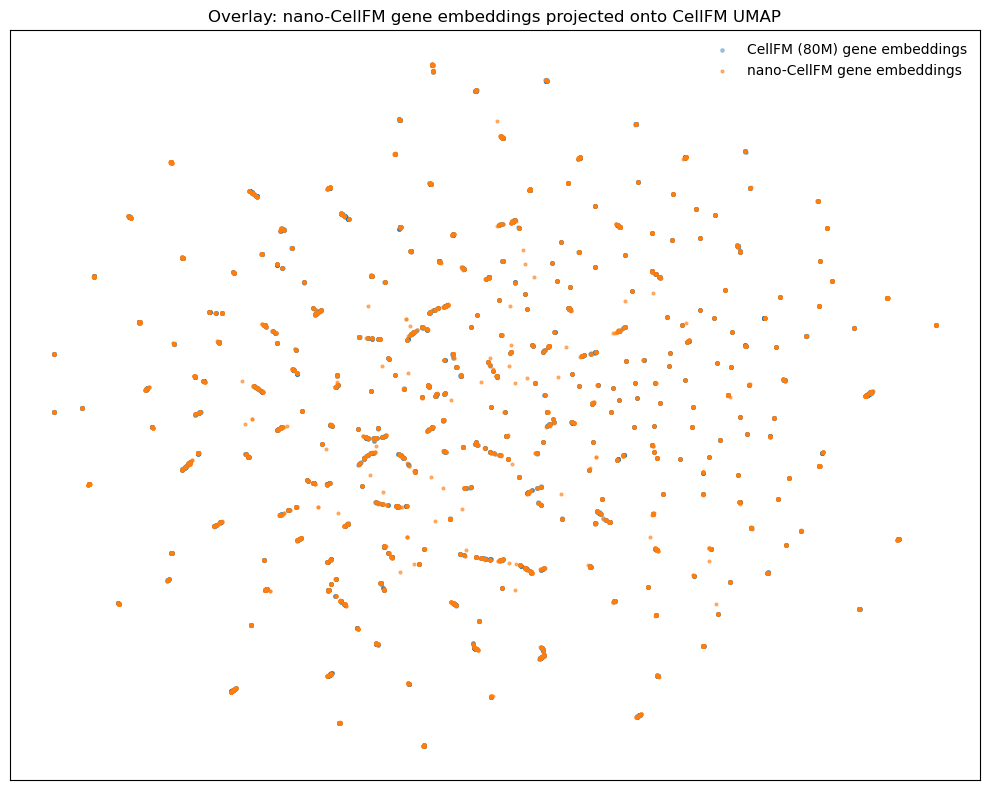

In [1]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

official = np.load("official_cellfm_gene_embeddings.npy")  # (N, G, 1536)
nano = np.load("nano_cellfm_gene_embeddings.npy")          # (N, G, 1536)

nano = nano[: official.shape[0]]
assert official.shape == nano.shape
print("official:", official.shape)
print("nano:", nano.shape)

official_flat = official.reshape(-1, official.shape[-1])
nano_flat = nano.reshape(-1, nano.shape[-1])

max_points = 5000
rng = np.random.default_rng(0)
idx = rng.choice(official_flat.shape[0], size=max_points, replace=False)

official_flat = official_flat[idx]
nano_flat = nano_flat[idx]

scaler = StandardScaler()
official_z = scaler.fit_transform(official_flat)
nano_z = scaler.transform(nano_flat)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
)

official_umap = reducer.fit_transform(official_z)
nano_umap = reducer.transform(nano_z)

plt.figure(figsize=(10, 8))

plt.scatter(
    official_umap[:, 0],
    official_umap[:, 1],
    s=6,
    alpha=0.35,
    label="CellFM (80M) gene embeddings",
)

plt.scatter(
    nano_umap[:, 0],
    nano_umap[:, 1],
    s=4,
    alpha=0.55,
    label="nano-CellFM gene embeddings",
)

plt.title("Overlay: nano-CellFM gene embeddings projected onto CellFM UMAP")
plt.legend(frameon=False)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig("overlay_cellfm80m_gene_embeddings.png", dpi=300)
plt.show()

# Cell Embedding Reproducibility

In [1]:
!python tasks/cell_embedding.py \
  --input pancreas.h5ad \
  --output nano_cellfm_cell_embeddings.npy \
  --batch-size 256 \
  --no-compile

#(N, 1536)

Saved embeddings: nano_cellfm_cell_embeddings.npy
Shape: (15681, 1536)


In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import scanpy as sc

from model import CellFM

official = np.load("official_cellfm_cell_embeddings.npy")  # (1,000, 1,536)

adata = sc.read_h5ad("pancreas.h5ad")
gene_info = pd.read_csv("assets/CellFM-80M/expand_gene_info.csv", index_col=0)

geneset = {g: i + 1 for i, g in enumerate(gene_info.index)}
gene_ids = np.array(
    [geneset[g] if g in geneset else 0 for g in adata.var_names],
    dtype=np.int64,
)

x = adata.X.A if hasattr(adata.X, "A") else np.asarray(adata.X)
x = x.astype(np.float32)

expr = torch.from_numpy(x[:1000])
gene = torch.from_numpy(gene_ids[None, :].repeat(1000, axis=0))

zero_gene_mask = (x[:1000] != 0).astype(np.float32)
zero_idx = torch.from_numpy(
    np.concatenate(
        [
            np.ones((zero_gene_mask.shape[0], 1), dtype=np.float32),
            zero_gene_mask,
        ],
        axis=1,
    )
)

model = CellFM.from_pretrained("CellFM-80M").eval()

with torch.no_grad():
    nano = model.encode_cells(expr, gene, zero_idx).cpu().numpy()
print(nano.shape)

off = torch.from_numpy(official)
nan = torch.from_numpy(nano)

cos = F.cosine_similarity(off, nan, dim=-1)

print("official CellFM:", official.shape)
print("nano-CellFM:", nano.shape)
print("mean cosine:", cos.mean().item())
print("median cosine:", cos.median().item())
print("min cosine:", cos.min().item())
print("mean abs diff:", torch.mean(torch.abs(off - nan)).item())
print("max abs diff:", torch.max(torch.abs(off - nan)).item())

(1000, 1536)
official CellFM: (1000, 1536)
nano-CellFM: (1000, 1536)
mean cosine: 1.0000001192092896
median cosine: 1.0000001192092896
min cosine: 1.0000001192092896
mean abs diff: 9.780572796103115e-09
max abs diff: 3.814697265625e-06


In [3]:
import time
import subprocess
import numpy as np

from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist


nano_path = "nano_cellfm_cell_embeddings.npy"

cmd = [
    "python", "tasks/cell_embedding.py",
    "--input", "pancreas.h5ad",
    "--output", nano_path,
    "--batch-size", "256",
    "--no-compile",
]

start = time.perf_counter()
subprocess.run(cmd, check=True)
elapsed = time.perf_counter() - start

nano = np.load(nano_path)

print("nano-CellFM:", nano.shape)

# -------------------------
# PCA spectrum
# -------------------------
n_pca = min(50, nano.shape[0], nano.shape[1])

pca = PCA(n_components=n_pca).fit(nano)

print("PCA explained variance ratio:")
print(pca.explained_variance_ratio_)

print("PCA spectrum cumulative variance:")
print(np.cumsum(pca.explained_variance_ratio_))

# -------------------------
# Pairwise distance structure
# -------------------------
nano_dist = pdist(nano, metric="euclidean")

print("Pairwise distance mean:", nano_dist.mean())
print("Pairwise distance std:", nano_dist.std())
print("Pairwise distance min:", nano_dist.min())
print("Pairwise distance max:", nano_dist.max())

# -------------------------
# Runtime metrics
# -------------------------
total_cells = nano.shape[0]
per_cell = elapsed / total_cells
throughput = total_cells / elapsed

print(f"Total ({total_cells:,} cells): {elapsed:.4f} s")
print(f"Per cell: {per_cell:.6f} s/cell")
print(f"Throughput: {throughput:.2f} cells/s")

Saved embeddings: nano_cellfm_cell_embeddings.npy
Shape: (15681, 1536)
nano-CellFM: (15681, 1536)
PCA explained variance ratio:
[1.0000192e+00 2.2079669e-14 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15
 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15 3.5527819e-15]
PCA spectrum cumulative variance:
[1.0000192 1.0000192 1.0000192 1.0000192 1.0000192 1.0000192 1.0000192
 1.0000192 1.0000192 1.0000192 1.0000192 1.0000192 1.000